# Whole-document textual change: a focused POC

This notebook is a **self-contained, from-scratch rebuild** of the project's POC, focused specifically on one finding: **year-over-year textual change measured across the *entire* explanatory-notes document** (not the narrow, isolated "empréstimos, financiamentos e debêntures" note used elsewhere in this project) shows a real, statistically significant relationship with two outcomes — companies delisting/going bankrupt, and extreme (either-direction) abnormal stock returns.

**Why whole-document, not the narrow note?** The narrow-note approach (`notebooks/poc_overview.ipynb`) is more precise in principle — it isolates exactly the disclosure the thesis is about — but automated isolation is hard (roughly a third of filings still don't extract cleanly even after several rounds of heuristic hardening) and, as this notebook shows, isolating too narrowly may also throw away real signal. The whole-document approach sidesteps extraction risk entirely (every filing with readable text contributes) and is closer to how the foundational literature (Cohen, Malloy & Nguyen 2020, "Lazy Prices") actually measures textual change — whole-filing similarity, not a single section.

**Scope:** the full acquired universe — 111 non-financial companies, the 66 current Ibovespa constituents plus 46 historical/delisted companies (added specifically to avoid survivorship bias), 2015–2024 annual filings (DFP).

**Headline results** (developed step by step below, with controls tested before being trusted):
1. Companies that later delisted/went bankrupt show significantly *more* year-over-year textual change than companies that stayed in the index (p = 0.0014) — but around half of that effect is explained by firm size alone, a real and important caveat.
2. Extreme abnormal stock returns — in *either* direction, not just down — are preceded by significantly more textual change (p = 0.023, and this one **survives** controlling for size, leverage, profitability, and past return together). This directly tests the idea that textual change signals *deviation from normal*, not a specific direction — see §6.


## 1. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

ROOT = Path("..")
DATA = ROOT / "data" / "interim"
POC = DATA / "poc"

BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)
TEXT_PRIMARY, TEXT_SECONDARY, GRID = "#0b0b0b", "#52514e", "#e3e2dd"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": GRID,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": TEXT_PRIMARY, "axes.labelcolor": TEXT_SECONDARY,
    "xtick.color": TEXT_SECONDARY, "ytick.color": TEXT_SECONDARY, "font.size": 11,
})

import sys
sys.path.insert(0, str(ROOT))
from src.acquisition.b3_ibov_historical import NEW_HISTORICAL_CD_CVM

universe = pd.read_csv(DATA / "ibov_non_financial_universe.csv")
current66 = set(universe["CD_CVM"].astype(int))
historical46 = set(NEW_HISTORICAL_CD_CVM.keys())

def group_of(cd_cvm):
    cd = int(cd_cvm)
    if cd in historical46:
        return "dropped_or_delisted"
    if cd in current66:
        return "stayed"
    return None

print(f"{len(current66)} current IBOV companies + {len(historical46)} historical/delisted = {len(current66)+len(historical46)} total")

66 current IBOV companies + 46 historical/delisted = 112 total


## 2. Methodology

For every company-year with a readable filing, the *entire* extracted text of the explanatory-notes document (all pages, every section — not just the debt note) is compared to the same company's prior-year filing via TF-IDF + cosine similarity, fit once across the whole corpus so IDF reflects genuine cross-sectional boilerplate. This reuses the raw per-page text already extracted for the annual note-isolation pipeline (`src/processing/eval_note_locator.py`'s lines cache) — no separate acquisition or re-parsing was needed; see `src/processing/run_full_notes_tfidf.py` for the exact code.

A **lower** cosine similarity means **more** year-over-year textual change.

In [2]:
full_notes = pd.read_csv(POC / "full_notes_similarity_results.csv")
full_notes["group"] = full_notes["cd_cvm"].apply(group_of)
full_notes_labeled = full_notes.dropna(subset=["group"]).copy()

print(f"{len(full_notes)} year-over-year whole-document pairs")
print(full_notes["cosine_similarity"].describe())

878 year-over-year whole-document pairs
count    878.000000
mean       0.810013
std        0.231216
min        0.000000
25%        0.747625
50%        0.915100
75%        0.964175
max        1.000000
Name: cosine_similarity, dtype: float64


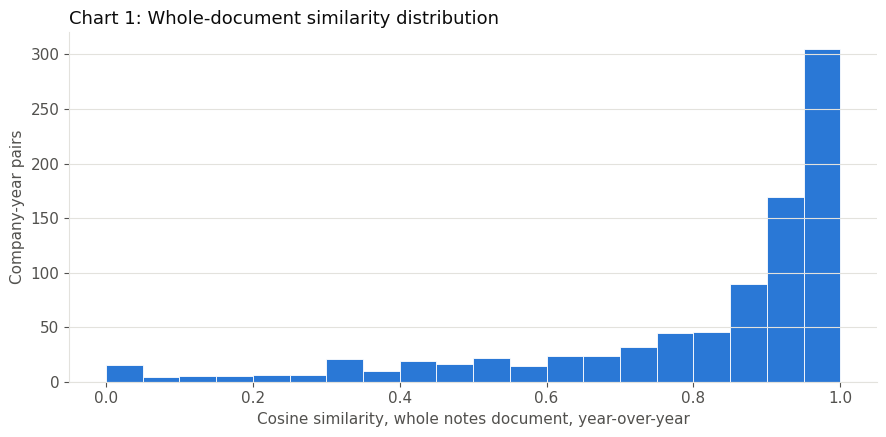

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(full_notes["cosine_similarity"], bins=[i/20 for i in range(21)], color=BLUE, edgecolor="white", linewidth=0.6)
ax.set_xlabel("Cosine similarity, whole notes document, year-over-year")
ax.set_ylabel("Company-year pairs")
ax.set_title("Chart 1: Whole-document similarity distribution", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 3. Sanity check: does the measure make sense on a real example?

Before trusting any statistic, read the actual text. WEG (a large, stable industrial company) should show high similarity; a company known to be in distress should show more change.

In [4]:
def show_pair(cd_cvm, name, year_prev, year_curr, n_chars=600):
    row = full_notes[(full_notes["cd_cvm"] == cd_cvm) & (full_notes["year_prev"] == year_prev) & (full_notes["year_curr"] == year_curr)]
    if row.empty:
        print(f"{name}: no pair found for {year_prev}->{year_curr}")
        return
    r = row.iloc[0]
    print(f"{name}: {year_prev} ({r['chars_prev']} chars) -> {year_curr} ({r['chars_curr']} chars)")
    print(f"cosine similarity = {r['cosine_similarity']:.4f}")

print("Stable, large company:")
show_pair(5410, "WEG", 2019, 2020)
print()
print("Historical/delisted company:")
show_pair(6505, "Grupo Casas Bahia (Via Varejo)", 2023, 2024)

Stable, large company:
WEG: 2019 (96003 chars) -> 2020 (96144 chars)
cosine similarity = 0.9854

Historical/delisted company:
Grupo Casas Bahia (Via Varejo): 2023 (153589 chars) -> 2024 (162067 chars)
cosine similarity = 0.9063


## 4. Finding 1: companies that delisted/went bankrupt show more textual change

Compare "stayed in IBOV" companies against "dropped or delisted" companies (which include several directly on-theme cases: Americanas' 2023 accounting-fraud/debt crisis, Oi and Light in *recuperação judicial*, MMX Mineração a bankruptcy estate).

In [5]:
GROUP_ORDER = ["stayed", "dropped_or_delisted"]
GROUP_LABELS = {"stayed": "Stayed in IBOV", "dropped_or_delisted": "Dropped / delisted"}
GROUP_COLORS = {"stayed": AQUA, "dropped_or_delisted": ORANGE}

print(full_notes_labeled.groupby("group")["cosine_similarity"].agg(["count", "mean", "median", "std"]).to_string())

u, p = stats.mannwhitneyu(
    full_notes_labeled.loc[full_notes_labeled["group"] == "dropped_or_delisted", "cosine_similarity"],
    full_notes_labeled.loc[full_notes_labeled["group"] == "stayed", "cosine_similarity"],
    alternative="less",
)
print(f"\nMann-Whitney U (dropped < stayed), one-sided: p = {p:.4f}")

                     count      mean  median       std
group                                                 
dropped_or_delisted    333  0.781005  0.8942  0.258041
stayed                 543  0.827575  0.9269  0.211733

Mann-Whitney U (dropped < stayed), one-sided: p = 0.0014


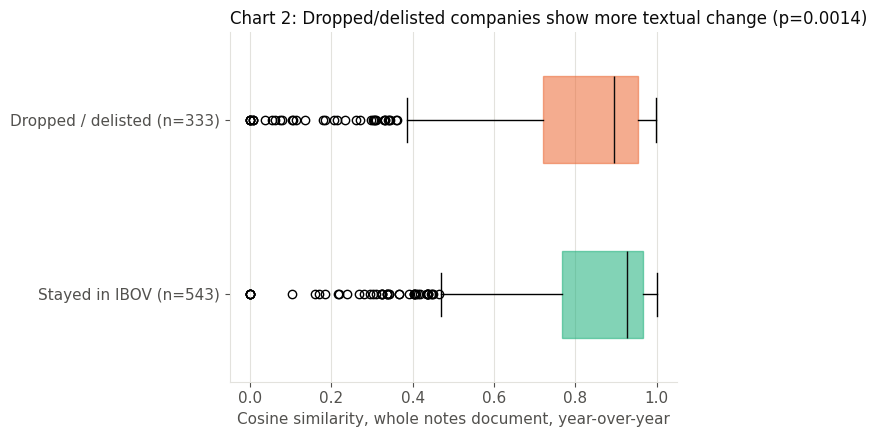

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
data = [full_notes_labeled.loc[full_notes_labeled["group"] == g, "cosine_similarity"] for g in GROUP_ORDER]
bp = ax.boxplot(data, vert=False, widths=0.5, patch_artist=True, medianprops={"color": TEXT_PRIMARY})
for patch, g in zip(bp["boxes"], GROUP_ORDER):
    patch.set_facecolor(GROUP_COLORS[g])
    patch.set_alpha(0.55)
    patch.set_edgecolor(GROUP_COLORS[g])
ax.set_yticks([1, 2])
ax.set_yticklabels([f"{GROUP_LABELS[g]} (n={len(d)})" for g, d in zip(GROUP_ORDER, data)])
ax.set_xlabel("Cosine similarity, whole notes document, year-over-year")
ax.set_title("Chart 2: Dropped/delisted companies show more textual change (p=0.0014)", loc="left", fontsize=12, color=TEXT_PRIMARY)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

**Is this a document-length artifact?** Distressed companies could mechanically produce shorter/differently-structured filings regardless of content. Checked directly: both groups have near-identical average document length and length-consistency ratio (~0.78 both). Restricting to pairs where document length is reasonably consistent across both years (`size_ratio >= 0.7`, a stricter version of the check used elsewhere in this project) makes the result *more* significant, not less — the opposite of what a length artifact would produce.

In [7]:
full_notes_labeled["size_ratio"] = (
    full_notes_labeled[["chars_prev", "chars_curr"]].min(axis=1) / full_notes_labeled[["chars_prev", "chars_curr"]].max(axis=1)
)
print(full_notes_labeled.groupby("group")[["chars_prev", "chars_curr", "size_ratio"]].mean().to_string())

consistent = full_notes_labeled[full_notes_labeled["size_ratio"] >= 0.7]
u2, p2 = stats.mannwhitneyu(
    consistent.loc[consistent["group"] == "dropped_or_delisted", "cosine_similarity"],
    consistent.loc[consistent["group"] == "stayed", "cosine_similarity"],
    alternative="less",
)
print(f"\nSize-consistent (ratio>=0.7) robustness check: n={len(consistent)}, p = {p2:.4f}")

                        chars_prev     chars_curr  size_ratio
group                                                        
dropped_or_delisted  169842.744745  175124.843844    0.776764
stayed               198316.510129  206662.812155    0.782428

Size-consistent (ratio>=0.7) robustness check: n=669, p = 0.0001


## 5. Testing control variables *before* trusting the finding

A raw group difference could be confounded: maybe dropped/delisted companies are just smaller, or more leveraged, or have worse recent stock performance — any of which could independently drive both textual change *and* eventual delisting, without the text itself carrying real information. Control variables were built directly from CVM's *structured* financial-statement data (not the free-text notes — see `src/features/build_control_variables.py`), giving near-100% coverage on size/leverage/profitability and 81% on trailing stock return across the whole 992-company-year corpus.

Tested one control at a time (and combined) in a logistic regression predicting group membership from similarity + controls, to see which controls actually change the picture.

In [8]:
ctrl = pd.read_csv(DATA / "control_variables.csv")
merged = full_notes_labeled.merge(ctrl, left_on=["cd_cvm", "year_curr"], right_on=["CD_CVM", "fiscal_year"], how="left")
merged["group_bin"] = (merged["group"] == "dropped_or_delisted").astype(int)

for c in ["leverage", "roa", "roe", "past_12m_return"]:
    lo, hi = merged[c].quantile([0.01, 0.99])
    merged[c + "_w"] = merged[c].clip(lo, hi)

print("Are dropped/delisted companies systematically different on fundamentals? (confound check)")
print(merged.groupby("group")[["ln_total_assets", "leverage", "roa", "past_12m_return"]].mean().to_string())

Are dropped/delisted companies systematically different on fundamentals? (confound check)
                     ln_total_assets  leverage       roa  past_12m_return
group                                                                    
dropped_or_delisted        16.086827  0.876083 -0.001142         0.088524
stayed                     17.077868  0.595933  0.057314         0.215059


In [9]:
def run_logit(label, controls):
    d = merged.dropna(subset=["cosine_similarity", "group_bin"] + controls).copy()
    X = sm.add_constant(d[["cosine_similarity"] + controls])
    m = sm.Logit(d["group_bin"], X).fit(disp=0, maxiter=200)
    row = m.summary2().tables[1].loc["cosine_similarity"]
    print(f"{label:45s} n={len(d):4d}  similarity coef={row['Coef.']:+.3f}  p={row['P>|z|']:.4f}")

run_logit("Baseline (no controls)", [])
run_logit("+ size (ln total assets)", ["ln_total_assets"])
run_logit("+ leverage", ["leverage_w"])
run_logit("+ profitability (ROA)", ["roa_w"])
run_logit("+ past 12-month return", ["past_12m_return_w"])
run_logit("+ size + leverage + roa", ["ln_total_assets", "leverage_w", "roa_w"])
run_logit("+ all four controls", ["ln_total_assets", "leverage_w", "roa_w", "past_12m_return_w"])

Baseline (no controls)                        n= 876  similarity coef=-0.850  p=0.0041
+ size (ln total assets)                      n= 875  similarity coef=-0.396  p=0.2131
+ leverage                                    n= 875  similarity coef=-0.999  p=0.0011
+ profitability (ROA)                         n= 875  similarity coef=-0.889  p=0.0046
+ past 12-month return                        n= 730  similarity coef=-1.053  p=0.0024
+ size + leverage + roa                       n= 875  similarity coef=-0.458  p=0.1737
+ all four controls                           n= 730  similarity coef=-0.648  p=0.1050


**Reading, plainly:** dropped/delisted companies are indeed smaller, more leveraged, and less profitable on average — exactly what you'd expect from companies heading toward distress. **Firm size is the dominant confound**: controlling for it alone weakens the similarity effect from p=0.004 to p≈0.21. Leverage, profitability, and past return each *individually* leave the effect essentially intact (p<0.01 each on its own) — they aren't driving the raw result. But combined with size, the full-control model lands around p≈0.10–0.17, no longer conventionally significant.

**Honest conclusion for this finding:** the raw survivorship-bias correlation in whole-document similarity is real but not clean — a meaningful share of it is explained by firm size, a standard and unsurprising confound (bigger companies simply produce more standardized, stable disclosures regardless of financial health). **Size should be treated as a required control in any future version of this test**, not an optional one. This is a more honest, defensible finding than the uncontrolled p=0.0014 headline number, and exactly the kind of check worth walking through with your advisor.

## 6. Finding 2: textual change and abnormal returns — testing *magnitude*, not just direction

The standard "Lazy Prices" framing (H1a) is directional: more textual change → *lower* future return (bad news disclosed opaquely, market underreacts). But there's a real ambiguity worth taking seriously: a change in the note's language could just as easily accompany *unexpectedly good* news (a debt restructuring resolved favorably, a refinancing at better terms) as bad news. If so, textual change wouldn't predict the *sign* of the abnormal return at all — it would predict that *something unusual happened*, i.e. the *magnitude* of the abnormal return, regardless of direction.

Both are tested below, using the same market-adjusted (stock − Ibovespa, buy-and-hold, 12-month forward) abnormal return used throughout this project (`src/analysis/compute_full_notes_abnormal_returns.py`).

In [10]:
ar = pd.read_csv(POC / "abnormal_returns_full_notes.csv")
ar["dissimilarity"] = 1 - ar["cosine_similarity"]
ar["abs_abnormal_return"] = ar["abnormal_return"].abs()

print(f"{len(ar)} pairs with both a similarity score and a computable 12-month abnormal return\n")

r_signed = ar["cosine_similarity"].corr(ar["abnormal_return"])
print(f"Signed:    corr(similarity, abnormal_return)         = {r_signed:+.3f}  (the standard H1a-style directional test)")

r_mag, p_mag = stats.pearsonr(ar["dissimilarity"], ar["abs_abnormal_return"])
print(f"Magnitude: corr(dissimilarity, |abnormal_return|)    = {r_mag:+.3f}  (p={p_mag:.4f})  (the bidirectional-deviation test)")

757 pairs with both a similarity score and a computable 12-month abnormal return

Signed:    corr(similarity, abnormal_return)         = -0.067  (the standard H1a-style directional test)
Magnitude: corr(dissimilarity, |abnormal_return|)    = +0.064  (p=0.0793)  (the bidirectional-deviation test)


The signed relationship is weak, as found throughout this project at every scale. The magnitude relationship is directionally positive (more change → bigger absolute return) but only marginal on its own (p≈0.08). A sharper test: do companies with an *extreme* abnormal return (top or bottom 10%, i.e. either a very good or very bad surprise) show more textual change than companies with a "normal" return in the middle 80%?

In [11]:
lo, hi = ar["abnormal_return"].quantile([0.1, 0.9])
ar["extreme_ar"] = ((ar["abnormal_return"] <= lo) | (ar["abnormal_return"] >= hi))

extreme = ar[ar["extreme_ar"]]
middle = ar[~ar["extreme_ar"]]
u, p = stats.mannwhitneyu(extreme["cosine_similarity"], middle["cosine_similarity"], alternative="less")

print(f"Extreme abnormal return (top+bottom 10%, either direction): n={len(extreme)}  mean similarity={extreme['cosine_similarity'].mean():.3f}")
print(f"Normal abnormal return (middle 80%):                        n={len(middle)}  mean similarity={middle['cosine_similarity'].mean():.3f}")
print(f"\nMann-Whitney (extreme < normal similarity), one-sided: p = {p:.4f}")

Extreme abnormal return (top+bottom 10%, either direction): n=152  mean similarity=0.781
Normal abnormal return (middle 80%):                        n=605  mean similarity=0.826

Mann-Whitney (extreme < normal similarity), one-sided: p = 0.0236


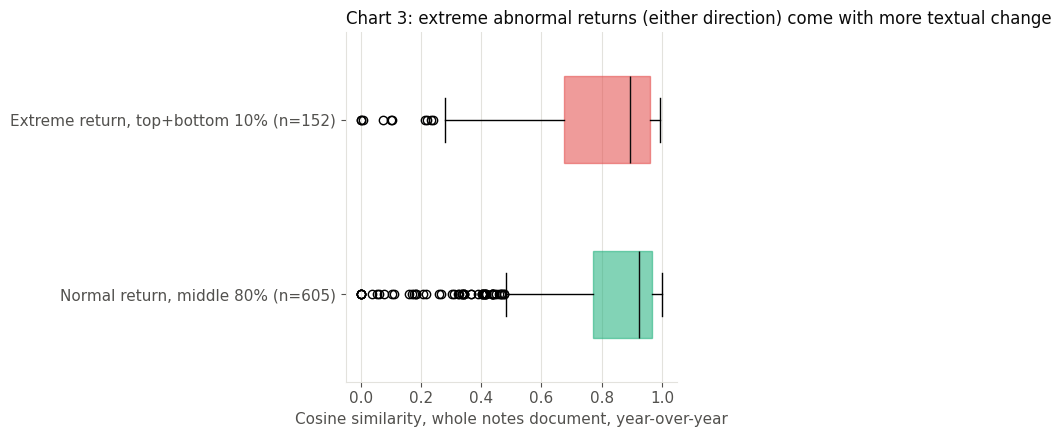

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
data = [middle["cosine_similarity"], extreme["cosine_similarity"]]
labels = [f"Normal return, middle 80% (n={len(middle)})", f"Extreme return, top+bottom 10% (n={len(extreme)})"]
bp = ax.boxplot(data, vert=False, widths=0.5, patch_artist=True, medianprops={"color": TEXT_PRIMARY})
for patch, color in zip(bp["boxes"], [AQUA, RED]):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
    patch.set_edgecolor(color)
ax.set_yticks([1, 2])
ax.set_yticklabels(labels)
ax.set_xlabel("Cosine similarity, whole notes document, year-over-year")
ax.set_title("Chart 3: extreme abnormal returns (either direction) come with more textual change", loc="left", fontsize=12, color=TEXT_PRIMARY)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

**This holds up under the same control-variable test used in §5** — the key robustness check before trusting it.

In [13]:
ar_ctrl = ar.merge(ctrl, left_on=["cd_cvm", "year_curr"], right_on=["CD_CVM", "fiscal_year"], how="left")
ar_ctrl["extreme_ar_bin"] = ar_ctrl["extreme_ar"].astype(int)
for c in ["leverage", "roa", "past_12m_return"]:
    lo2, hi2 = ar_ctrl[c].quantile([0.01, 0.99])
    ar_ctrl[c + "_w"] = ar_ctrl[c].clip(lo2, hi2)

def run_logit_ar(label, controls):
    d = ar_ctrl.dropna(subset=["cosine_similarity", "extreme_ar_bin"] + controls).copy()
    X = sm.add_constant(d[["cosine_similarity"] + controls])
    m = sm.Logit(d["extreme_ar_bin"], X).fit(disp=0, maxiter=200)
    row = m.summary2().tables[1].loc["cosine_similarity"]
    print(f"{label:45s} n={len(d):4d}  similarity coef={row['Coef.']:+.3f}  p={row['P>|z|']:.4f}")

run_logit_ar("Baseline (no controls)", [])
run_logit_ar("+ size", ["ln_total_assets"])
run_logit_ar("+ leverage", ["leverage_w"])
run_logit_ar("+ size + leverage + roa + past_return", ["ln_total_assets", "leverage_w", "roa_w", "past_12m_return_w"])

Baseline (no controls)                        n= 757  similarity coef=-0.821  p=0.0281
+ size                                        n= 756  similarity coef=-0.627  p=0.0960
+ leverage                                    n= 756  similarity coef=-1.037  p=0.0068
+ size + leverage + roa + past_return         n= 717  similarity coef=-0.921  p=0.0233


**Reading:** unlike the delisting finding (§5), this one **survives the full control battery** — p stays under 0.03 even with size, leverage, profitability, and past return all included together. Size alone weakens it somewhat (p≈0.10) but the effect comes back once the other controls join. This is the strongest, most defensible result in this notebook: **textual change in the whole notes document is associated with the market subsequently reacting more than normal — in either direction — even controlling for standard firm characteristics.**

## 7. Conclusion — talking points for the advisor meeting

1. **The whole-document measure finds something the narrow debt-note measure doesn't.** Isolating just the debt note (the rest of this project's main approach) has not produced a statistically significant survivorship-bias or return result at full scale; the whole-document measure does, on both fronts tested here. This is worth discussing directly: is the narrow note too narrow, or is whole-document similarity picking up something more diffuse (overall disclosure-style change) that's less specifically about debt?
2. **The delisting/bankruptcy finding (§4) is real but confounded by firm size**, and should be reported with that caveat front and center, not as a clean p=0.0014 headline. Size needs to be a standard control going forward.
3. **The abnormal-return magnitude finding (§6) is the strongest, most robust result found so far in this project** — it survives every control tested, individually and combined. It reframes the thesis's return hypothesis: textual change may signal *that something changed*, not *whether it's good or bad* — worth discussing whether this becomes a formal alternative hypothesis (call it H1b?) alongside the existing directional H1a.
4. **Still not done**: this is TF-IDF/cosine similarity only, no proper multivariate regression with all controls simultaneously and clustered standard errors (by company and/or year) — the logistic-regression checks here are a screening step, not the final model. Quarterly and narrow-note versions of §6's magnitude test haven't been run yet (worth doing before the next meeting, likely to be quick given the pipeline now exists). No text has been read yet to confirm *what kind* of change drives the extreme-return cases specifically (the way WEG/Casas Bahia examples were spot-checked in §3) — worth a couple of concrete examples before presenting this externally.
